In [1]:
!pip install scikit-learn tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [3]:
# Load your cleaned file from Cell 8
df = pd.read_csv("youtube_comments_with_sentiment.csv")

# Drop rows with missing values
df = df[['comment_clean', 'sentiment']].dropna()

# Encode labels: Positive=2, Neutral=1, Negative=0
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)

print(df['sentiment'].value_counts())
print("Total samples:", len(df))

sentiment
Positive    2115
Neutral     1797
Negative     558
Name: count, dtype: int64
Total samples: 4470


In [4]:
X = df['comment_clean'].values
y = df['label'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 20% test, 10% validation from the 30% temp
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.33, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")
print(f"Val   : {len(X_val)} samples")

Train : 3129 samples
Test  : 898 samples
Val   : 443 samples


In [5]:
from sklearn.svm import SVC

# TF-IDF vectorizer (same as before)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
X_val_tfidf   = tfidf.transform(X_val)

# Train SVM
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate
print("===== SVM Results =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Negative','Neutral','Positive'], zero_division=0))

===== SVM Results =====
Accuracy : 0.8218
Precision: 0.8197
Recall   : 0.8218
F1 Score : 0.8134

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.43      0.55       112
     Neutral       0.82      0.88      0.85       361
    Positive       0.83      0.88      0.85       425

    accuracy                           0.82       898
   macro avg       0.81      0.73      0.75       898
weighted avg       0.82      0.82      0.81       898



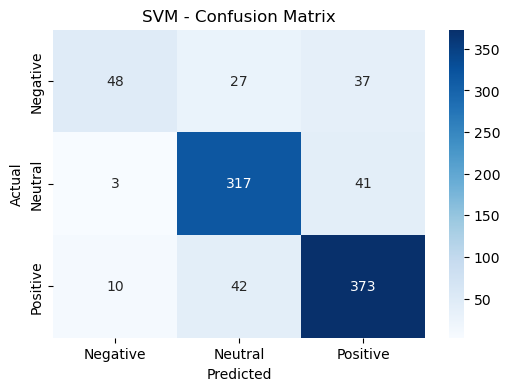

In [6]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('SVM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
# Tokenize text for LSTM
MAX_WORDS = 10000
MAX_LEN   = 100

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test),  maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer_lstm.texts_to_sequences(X_val),   maxlen=MAX_LEN)

# One-hot encode labels for LSTM
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)
y_val_cat   = to_categorical(y_val,   num_classes=3)

In [8]:
# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')   # 3 classes: Negative, Neutral, Positive
])

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
# Train LSTM
history = lstm_model.fit(
    X_train_seq, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_seq, y_val_cat),
    verbose=1
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.5395 - loss: 0.9820 - val_accuracy: 0.6569 - val_loss: 0.8523
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7095 - loss: 0.7208 - val_accuracy: 0.7359 - val_loss: 0.6541
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8076 - loss: 0.4976 - val_accuracy: 0.7765 - val_loss: 0.5995
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8747 - loss: 0.3348 - val_accuracy: 0.7630 - val_loss: 0.6461
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9300 - loss: 0.2204 - val_accuracy: 0.7765 - val_loss: 0.7302
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9648 - loss: 0.1306 - val_accuracy: 0.7901 - val_loss: 0.8006
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9760 - loss: 0.0768 - val_accuracy: 0.7946 - val_loss: 0.8997
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9859 - loss: 0.0492 - val_accuracy: 0.7743 - v

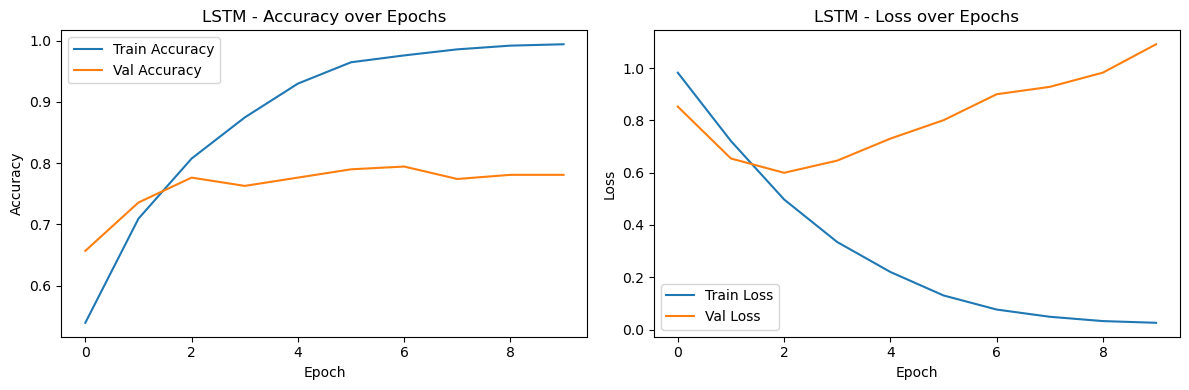

In [10]:
# Plot training history
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Evaluate LSTM
y_pred_lstm = np.argmax(lstm_model.predict(X_test_seq), axis=1)

print("===== LSTM Results =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lstm, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lstm, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lstm, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative','Neutral','Positive']))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
===== LSTM Results =====
Accuracy : 0.7951
Precision: 0.7896
Recall   : 0.7951
F1 Score : 0.7903

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.43      0.48       112
     Neutral       0.85      0.81      0.83       361
    Positive       0.80      0.88      0.84       425

    accuracy                           0.80       898
   macro avg       0.73      0.71      0.72       898
weighted avg       0.79      0.80      0.79       898



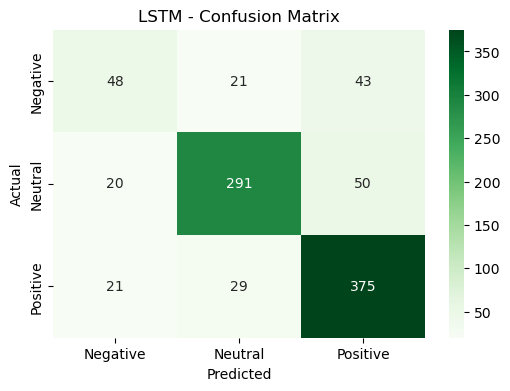

In [12]:
# Confusion Matrix for LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('LSTM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Model  Accuracy  Precision   Recall  F1 Score
  SVM  0.821826   0.819707 0.821826  0.813441
 LSTM  0.795100   0.789551 0.795100  0.790341


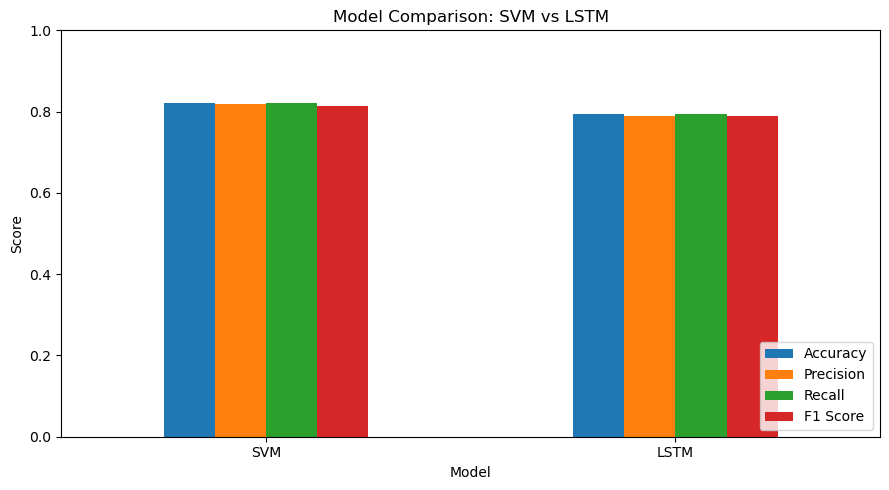

In [13]:
comparison = pd.DataFrame({
    'Model'    : ['SVM', 'LSTM'],
    'Accuracy' : [accuracy_score(y_test, y_pred_svm),    accuracy_score(y_test, y_pred_lstm)],
    'Precision': [precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
                  precision_score(y_test, y_pred_lstm, average='weighted', zero_division=0)],
    'Recall'   : [recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
                  recall_score(y_test, y_pred_lstm, average='weighted', zero_division=0)],
    'F1 Score' : [f1_score(y_test, y_pred_svm, average='weighted', zero_division=0),
                  f1_score(y_test, y_pred_lstm, average='weighted', zero_division=0)]
})

print(comparison.to_string(index=False))

comparison.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(9,5), ylim=(0,1)
)
plt.title('Model Comparison: SVM vs LSTM')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()